# MSD Postselection Experiment

This notebook wires together the experimental `PostSelectionExperiment`
scaffold for three cases:

- distilled MSD with an MLD table decoder,
- distilled MSD with an MLE decoder,
- injected-state tomography with a degenerate no-ancilla MLD table decoder.

The default shot counts are intentionally small so the notebook can run as a
smoke test. Increase the constants below to approach the paper-scale curves.



In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
from bloqade.lanes import GeminiLogicalSimulator

try:
    REPO_ROOT = Path(__file__).resolve().parents[1]
except NameError:
    REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "demo":
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from bloqade.gemini.decoding.workflow import plot_decoder_curves

from demo.msd_utils.application.experiments import (
    PostSelectionExperiment,
    empty_logical_circuit,
    magic_state_dist_steane,
    single_qubit_state_tomography,
)
from demo.msd_utils.application.table_decoders import TableDecoderWithSimplerConfidence
from demo.msd_utils.domain.confidence import ConfidenceGurobiDecoder
from demo.msd_utils.standard.tomography import DEFAULT_TARGET_BLOCH



## Configuration



In [ ]:
# TODO: maybe not have all the variables defined near the top? -- make dependencies clear between variables and functions

EVAL_SHOTS = 1_000_000
MLD_TRAIN_SHOTS = 10_000_000
MLD_BATCH_SIZE = None
# TODO: subclass a device object (? -- probably not the best idea)
SIM_TYPE = "clifft"

# TODO, pers: get rid of BINARY_PRECISION
BINARY_PRECISION = 4
# TODO: put these below in a different cell for configurations (for analysis configurations)
THRESHOLD_POINTS = 24
MIN_ACCEPTED_PER_BASIS = 50

# TODO pers: get rid of SPECIAL_KERNEL_STRATEGY and just use compiled_inverse_prefix
SPECIAL_KERNEL_STRATEGY = "compiled_inverse_prefix"
# TOTALK: variable names in functions
# TODO: remove these when I merge main in.

MSD_VALID_FACTORY_TARGETS = np.array([[1, 0, 1, 1]], dtype=np.uint8)
INJECTED_VALID_FACTORY_TARGETS = np.zeros((1, 0), dtype=np.uint8)



## Shared kernels



In [3]:
# TODO: check if we want to use dataclass or named tuple
primitive_set = magic_state_dist_steane()
noncliff_prefix = primitive_set.state_injection_circuit
main_cliff_circ = primitive_set.logical_circuit
# TODO: down the line, dictionary is OK, but a mapping from Pauli Strings to whatever. Can support normal strings
# can change the paulidict for now.
tomo_circs = single_qubit_state_tomography()



Building MSD primitives...


## Experiment construction



In [ ]:
def build_msd_mld_experiment() -> PostSelectionExperiment:
    return PostSelectionExperiment(
        noncliff_prefix,
        main_cliff_circ,
        # TODO: allow for injection for tomography. have a default for single-qubit. -- delete tomo_circs, and document the assumption what tomography is being used.
        # TODO: note that in the future, we can add more tomography types.
        tomo_circs,
        MSD_VALID_FACTORY_TARGETS,
        TableDecoderWithSimplerConfidence,
        # TODO: this should be the arguments to pass in to the decoder constructor
        {
            "num_shots": MLD_TRAIN_SHOTS,
            # TODO: use defaults.
            "step_size": MLD_BATCH_SIZE,
            # TODO: can remove
        },
        # TODO: can get rid of this
        target_bloch=DEFAULT_TARGET_BLOCH,
    )


def build_msd_mle_experiment() -> PostSelectionExperiment:
    return PostSelectionExperiment(
        noncliff_prefix,
        main_cliff_circ,
        tomo_circs,
        MSD_VALID_FACTORY_TARGETS,
        ConfidenceGurobiDecoder,
        {},
        # TODO: get rid of this
        target_bloch=DEFAULT_TARGET_BLOCH,
    )


def build_injected_mld_experiment() -> PostSelectionExperiment:
    return PostSelectionExperiment(
        noncliff_prefix,
        empty_logical_circuit(),
        tomo_circs,
        INJECTED_VALID_FACTORY_TARGETS,
        TableDecoderWithSimplerConfidence,
        {
            # TODO: in principle, reduce the number of arguments passed in here?
            "num_shots": MLD_TRAIN_SHOTS,
            # TODO: get rid of this
            "step_size": MLD_BATCH_SIZE,
            # TODO: can remove sim_type
        },
        # TODO: get rid of this
        target_bloch=DEFAULT_TARGET_BLOCH,
    )

# TODO: skip the function; just call the constructor.
msd_mld_exp = build_msd_mld_experiment()
msd_mle_exp = build_msd_mle_experiment()
injected_mld_exp = build_injected_mld_experiment()



## End-to-end runner



In [5]:
def prepare_experiment(
    exp: PostSelectionExperiment,
    *,
    decoder_name: str,
    num_logical_qubits: int,
    eval_shots: int = EVAL_SHOTS,
) -> PostSelectionExperiment:
    # TODO: "Exp" object should have good visualization methods -- defends why we are making it stateful -- for the future.
    exp.kernels(
        # TODO: drop num_logical_qubits --> looking through the kernels, and figuring out the number of qubits, etc. -- can be skippable.
        num_logical_qubits=num_logical_qubits,
        # TODO: can hardcode the output_qubit to 0.
        output_qubit=0,
        special_kernel_strategy=SPECIAL_KERNEL_STRATEGY,
    )
    exp.dem_circuits(special_kernel_strategy=SPECIAL_KERNEL_STRATEGY)
    exp.dems()
    exp.initialize_decoders()
    exp.make_tasks(device=GeminiLogicalSimulator())
    # TODO: get rid of SIM_TYPE
    exp.get_samples(num_shots=eval_shots, chunk_size=None, sim_type=SIM_TYPE)
    # TODO: get this from "introspection"?
    exp.decode_and_postselect(decoder_name=decoder_name)
    return exp

In [6]:
injected_mld_exp = prepare_experiment(
    injected_mld_exp,
    decoder_name="Injected MLD",
    num_logical_qubits=1,
)

100%|██████████| 1/1 [00:00<00:00, 50.02it/s]


Injected MLD X: factory decode:   0%|          | 0/1000000 [00:00<?, ?shots/s]

Injected MLD Y: factory decode:   0%|          | 0/1000000 [00:00<?, ?shots/s]

Injected MLD Z: factory decode:   0%|          | 0/1000000 [00:00<?, ?shots/s]

In [7]:
injected_summary = injected_mld_exp.tomography_result(
    1.0,
    "wilson",
    binary_precision=BINARY_PRECISION,
).fidelity_bloch(DEFAULT_TARGET_BLOCH)

In [8]:
injected_summary

{'point': 0.965370297728952}

In [9]:
msd_mld_exp = prepare_experiment(
    msd_mld_exp,
    decoder_name="MLD",
    num_logical_qubits=5,
)


100%|██████████| 1/1 [00:00<00:00,  1.20it/s]


MLD X: factory decode:   0%|          | 0/1000000 [00:00<?, ?shots/s]

MLD Y: factory decode:   0%|          | 0/1000000 [00:00<?, ?shots/s]

MLD Z: factory decode:   0%|          | 0/1000000 [00:00<?, ?shots/s]

## Tomography result API



In [10]:
# NOTE: this should just have the shot counts.
tomo_result = msd_mld_exp.tomography_result(
    1.0,
    "wilson",
    binary_precision=BINARY_PRECISION,
)

# tomo_result should be a density matrix
# TODO: can add more functions/type checks on the inptu later -- for the future.
tomo_result.fidelity_bloch(DEFAULT_TARGET_BLOCH)



{'point': 0.943386310178274}

In [11]:
injected_summary = injected_mld_exp.tomography_result(
    1.0,
    "wilson",
    binary_precision=BINARY_PRECISION,
).fidelity_bloch(DEFAULT_TARGET_BLOCH)

In [12]:
injected_summary

{'point': 0.965370297728952}

In [13]:
try:
    msd_mle_exp = prepare_experiment(
        msd_mle_exp,
        decoder_name="MLE",
        num_logical_qubits=5,
    )
except Exception as exc:
    print(f"Skipping MLE experiment because decoder construction failed: {exc!r}")
    msd_mle_exp = None

Restricted license - for non-production use only - expires 2027-11-29


MLE X: factory decode:   0%|          | 0/1000000 [00:00<?, ?shots/s]

MLE Y: factory decode:   0%|          | 0/1000000 [00:00<?, ?shots/s]

MLE Z: factory decode:   0%|          | 0/1000000 [00:00<?, ?shots/s]

Restricted license - for non-production use only - expires 2027-11-29


## Curves



In [14]:
msd_mld_curve = msd_mld_exp.analysis_f_vs_fraction(
    # TODO: remove the first two arguments.
    binary_precision=BINARY_PRECISION,

    target_bloch=DEFAULT_TARGET_BLOCH,
    threshold_points=THRESHOLD_POINTS,
    min_accepted_per_basis=MIN_ACCEPTED_PER_BASIS,
    # TODO: get rid of this argument completely -- introduce more things with a default arguments.
    uncertainty_backend="wilson",
)

# TODO: ancilla? (Put the ancilla confidence stuff in a draft PR -- remove the ancilla score stuff from final PR) -- keep the branch with the ancilla confidence somewhere, so that the code is not lost.
# TODO: have a default argument for the BINARY_PRECISION; make the demo notebook simpler
# TODO: hide the impl with a default argument if possible; in the demo notebook. -- on purpose
# one that is pedagogical and pretty, and another that is quickly to see all parameters.
msd_mle_curve = None
if msd_mle_exp is not None:
    msd_mle_curve = msd_mle_exp.analysis_f_vs_fraction(
        # TODO: remove the first two args
        binary_precision=BINARY_PRECISION,
        target_bloch=DEFAULT_TARGET_BLOCH,
        threshold_points=THRESHOLD_POINTS,
        min_accepted_per_basis=MIN_ACCEPTED_PER_BASIS,
        # TODO: get rid of this argument completely -- introduce more things with a default arguments.

        uncertainty_backend="wilson",
    )

injected_curve = injected_mld_exp.analysis_f_vs_fraction(
    # TODO: remove the first two args
    binary_precision=BINARY_PRECISION,
    target_bloch=DEFAULT_TARGET_BLOCH,
    threshold_points=THRESHOLD_POINTS,
    min_accepted_per_basis=MIN_ACCEPTED_PER_BASIS,
    # TODO: get rid of this argument completely -- introduce more things with a default arguments.

    uncertainty_backend="wilson",
)



In [15]:
msd_mld_curve

{'accepted_fraction': array([0.03598033, 0.03732867, 0.04266933, 0.04808933, 0.053267  ,
        0.05888567, 0.06402933, 0.069721  , 0.07489933, 0.08020233,
        0.085334  , 0.09065233, 0.09599167, 0.10131333, 0.10665567,
        0.111984  , 0.11731   , 0.122642  ]),
 'fidelity': array([0.99593714, 0.99604124, 0.99289081, 0.99066635, 0.99059237,
        0.98926293, 0.98840488, 0.98818677, 0.98760704, 0.98680802,
        0.98432948, 0.9815778 , 0.97623733, 0.97255582, 0.96788954,
        0.96230038, 0.95437068, 0.94338631]),
 'point_fidelity': array([0.99593714, 0.99604124, 0.99289081, 0.99066635, 0.99059237,
        0.98926293, 0.98840488, 0.98818677, 0.98760704, 0.98680802,
        0.98432948, 0.9815778 , 0.97623733, 0.97255582, 0.96788954,
        0.96230038, 0.95437068, 0.94338631]),
 'credible': array([[0.99170966, 1.00016461],
        [0.99189036, 1.00019212],
        [0.98899707, 0.99678456],
        [0.98699068, 0.99434202],
        [0.98709904, 0.99408571],
        [0.985935

In [16]:
injected_summary

{'point': 0.965370297728952}

## Individual visualizations



Plotting decoder curves...
Plotting decoder curves...
Plotting decoder curves...


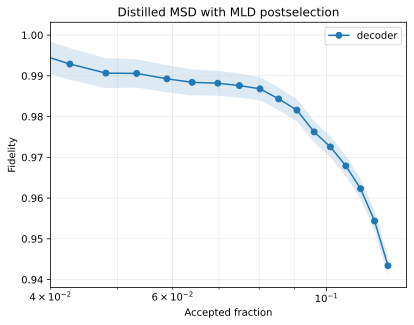

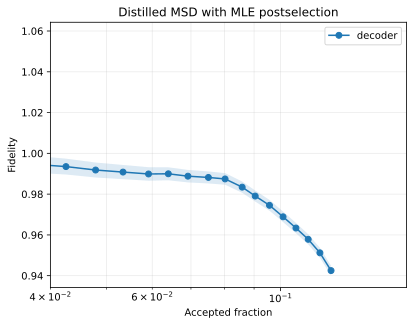

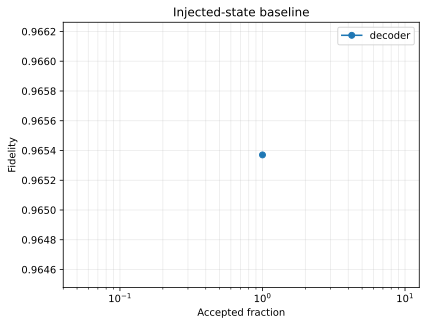

In [17]:
fig_mld, ax_mld = msd_mld_exp.analysis_visualization(
    min_accepted_fraction=0.04,
    title="Distilled MSD with MLD postselection",
)

if msd_mle_exp is not None:
    fig_mle, ax_mle = msd_mle_exp.analysis_visualization(
        min_accepted_fraction=0.04,
        title="Distilled MSD with MLE postselection",
    )

fig_injected, ax_injected = injected_mld_exp.analysis_visualization(
    min_accepted_fraction=0.04,
    title="Injected-state baseline",
)



## Combined figure



Plotting decoder curves...


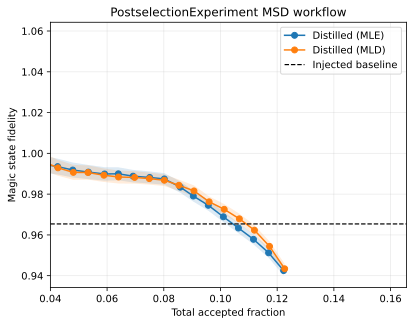

In [18]:
curves = {"Distilled (MLD)": msd_mld_curve}
if msd_mle_curve is not None:
    curves = {"Distilled (MLE)": msd_mle_curve, **curves}

fig, ax = plot_decoder_curves(
    curves,
    injected_summary=injected_summary,
    min_accepted_fraction=0.04,
    title="PostselectionExperiment MSD workflow",
)
ax.set_xscale("linear")
ax.set_xlabel("Total accepted fraction")
ax.set_ylabel("Magic state fidelity")
ax.legend()


# debug

In [19]:
import numpy as np

def summarize_curve(name, curve):
    print(f"\n{name}")
    print("keys:", curve.keys())

    for key in ["accepted_fraction", "fidelity", "credible", "low", "high", "median", "point", "error"]:
        if key not in curve:
            continue
        arr = np.asarray(curve[key])
        print(
            key,
            "shape=", arr.shape,
            "dtype=", arr.dtype,
            "min=", np.nanmin(arr) if arr.size else None,
            "max=", np.nanmax(arr) if arr.size else None,
        )

    credible = np.asarray(curve.get("credible", []), dtype=float)
    accepted = np.asarray(curve.get("accepted_fraction", []), dtype=float)
    fidelity = np.asarray(curve.get("fidelity", []), dtype=float)

    if credible.shape == (len(accepted), 2) and len(accepted):
        idx = int(np.nanargmin(credible[:, 0]))
        print("lowest credible interval row:")
        print("  idx:", idx)
        print("  accepted:", accepted[idx])
        print("  fidelity:", fidelity[idx])
        print("  low:", credible[idx, 0])
        print("  high:", credible[idx, 1])

summarize_curve("MLD", msd_mld_curve)

if msd_mle_curve is not None:
    summarize_curve("MLE", msd_mle_curve)

print("\ninjected_summary")
print(injected_summary)


MLD
keys: dict_keys(['accepted_fraction', 'fidelity', 'point_fidelity', 'credible'])
accepted_fraction shape= (18,) dtype= float64 min= 0.035980333333333336 max= 0.122642
fidelity shape= (18,) dtype= float64 min= 0.943386310178274 max= 0.9960412397249672
credible shape= (18, 2) dtype= float64 min= 0.9409858908406187 max= 1.00019212426627
lowest credible interval row:
  idx: 17
  accepted: 0.122642
  fidelity: 0.943386310178274
  low: 0.9409858908406187
  high: 0.9457867295159293

MLE
keys: dict_keys(['accepted_fraction', 'fidelity', 'point_fidelity', 'credible'])
accepted_fraction shape= (19,) dtype= float64 min= 0.00030233333333333333 max= 0.12227733333333334
fidelity shape= (19,) dtype= float64 min= 0.9424954088676 max= 1.0131206582015828
credible shape= (19, 2) dtype= float64 min= 0.9400902614799188 max= 1.0583811650226216
lowest credible interval row:
  idx: 18
  accepted: 0.12227733333333334
  fidelity: 0.9424954088676
  low: 0.9400902614799188
  high: 0.9449005562552811

injecte

Plotting decoder curves...
ylim: (np.float64(0.9341757163027836), np.float64(1.0642957101997568))
collection 0 y min/max: 0.9400902614799188 1.0583811650226216
collection 1 y min/max: 0.9409858908406187 1.00019212426627
line 0 Distilled (MLE) y min/max: 0.9424954088676 1.0131206582015828
line 1 Distilled (MLD) y min/max: 0.943386310178274 0.9960412397249672
line 2 Injected baseline y min/max: 0.965370297728952 0.965370297728952


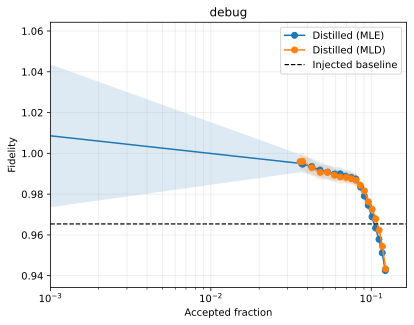

In [20]:
fig, ax = plot_decoder_curves(
    curves,
    injected_summary=injected_summary,
    min_accepted_fraction=0.001,
    title="debug",
)
print("ylim:", ax.get_ylim())

for i, collection in enumerate(ax.collections):
    try:
        paths = collection.get_paths()
        ys = np.concatenate(
            [
                np.asarray(p.vertices, dtype=float)[:, 1]
                for p in paths
                if np.asarray(p.vertices).size
            ]
        )
        print("collection", i, "y min/max:", np.nanmin(ys), np.nanmax(ys))
    except Exception as exc:
        print("collection", i, "could not inspect:", exc)

for i, line in enumerate(ax.lines):
    y = np.asarray(line.get_ydata(), dtype=float)
    print("line", i, line.get_label(), "y min/max:", np.nanmin(y), np.nanmax(y))